# CertCF network-complexity scaling

This notebook validates and analyzes the fixed 5 × 5 ReLU MLP grid. It reports one seed only; no across-seed error bars are implied.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULT_DIR = ROOT / 'results' / 'network_complexity'
queries = pd.read_parquet(RESULT_DIR / 'network_complexity_queries.parquet')
summary = pd.read_parquet(RESULT_DIR / 'network_complexity_summary.parquet')
assert summary['architecture_id'].nunique() == 25, 'Expected 25 complete architectures'
assert len(queries) == 25_000, 'Expected 25,000 query rows'
summary

,architecture_id,depth,width,parameter_count,classifier_test_accuracy,classifier_query_accuracy,training_time_s,build_wall_time_s,build_rss_baseline_bytes,build_rss_peak_bytes,...,eps_initial_max,eps_final_min,eps_final_median,eps_final_max,adaptive_eps_shrunk_count,adaptive_eps_shrink_total,adaptive_eps_shrink_max,adaptive_eps_center_certified_fraction,validity,n_queries
0,depth_01_width_016,1,16,562,0.980,0.980,7.511265,13.590069,1640632320,1643560960,...,7.666320,0.246791,2.702991,7.666320,624,703,4,1.0,1.0,1000
1,depth_01_width_032,1,32,1122,0.982,0.982,7.778868,14.401450,1645641728,1647214592,...,7.298794,0.214862,2.551330,6.988051,752,807,4,1.0,1.0,1000
2,depth_01_width_064,1,64,2242,0.982,0.982,7.256551,15.830139,1654509568,1655570432,...,7.213135,0.257797,2.465308,6.744990,899,985,4,1.0,1.0,1000
3,depth_01_width_128,1,128,4482,0.981,0.981,6.941664,16.373788,1658695680,1659756544,...,7.022397,0.292306,2.465272,6.797491,951,1043,4,1.0,1.0,1000
4,depth_01_width_256,1,256,8962,0.983,0.983,7.260759,16.200024,1661939712,1662824448,...,7.119475,0.395010,2.442767,6.699873,972,1056,3,1.0,1.0,1000
5,depth_02_width_016,2,16,834,0.979,0.979,8.009746,23.745322,1666682880,1668935680,...,7.642430,0.409934,2.447604,6.645624,934,1113,3,1.0,1.0,1000
6,depth_02_width_032,2,32,2178,0.981,0.981,7.878859,26.097542,1678073856,1680797696,...,7.662685,0.306525,2.382817,5.973208,991,1202,4,1.0,1.0,1000
7,depth_02_width_064,2,64,6402,0.978,0.978,8.005172,32.629047,1688350720,1689407488,...,7.594542,0.240605,2.206125,3.797271,1000,1452,4,1.0,1.0,1000
8,depth_02_width_128,2,128,20994,0.979,0.979,7.795536,39.681095,1693401088,1694326784,...,7.642430,0.370563,2.363898,4.404101,999,1297,4,1.0,1.0,1000
9,depth_02_width_256,2,256,74754,0.978,0.978,7.883932,68.895231,1698410496,1699672064,...,7.427016,0.148004,1.343542,3.669625,1000,1675,5,1.0,1.0,1000


## Complete per-architecture table

In [2]:
table_columns = [
    'depth', 'width', 'parameter_count', 'classifier_test_accuracy',
    'build_wall_time_s', 'build_rss_peak_delta_bytes',
    'build_cuda_peak_allocated_bytes', 'validity',
    'query_time_median_s', 'query_time_p95_s', 'atlas_region_count',
]
summary[table_columns].sort_values(['depth', 'width']).style.format({
    'classifier_test_accuracy': '{:.2%}', 'validity': '{:.2%}',
    'build_wall_time_s': '{:.2f}', 'query_time_median_s': '{:.4f}',
    'query_time_p95_s': '{:.4f}',
})

,depth,width,parameter_count,classifier_test_accuracy,build_wall_time_s,build_rss_peak_delta_bytes,build_cuda_peak_allocated_bytes,validity,query_time_median_s,query_time_p95_s,atlas_region_count
0,1,16,562,98.00%,13.59,2928640,9583616,100.00%,0.1273,0.2093,1000
1,1,32,1122,98.20%,14.40,1572864,9589760,100.00%,0.1273,0.2090,1000
2,1,64,2242,98.20%,15.83,1060864,9602048,100.00%,0.1273,0.2090,1000
3,1,128,4482,98.10%,16.37,1060864,9628160,100.00%,0.1268,0.2084,1000
4,1,256,8962,98.30%,16.20,884736,9682432,100.00%,0.1274,0.2098,1000
5,2,16,834,97.90%,23.75,2252800,9588224,100.00%,0.1244,0.2028,1000
6,2,32,2178,98.10%,26.10,2723840,9603584,100.00%,0.1254,0.2060,1000
7,2,64,6402,97.80%,32.63,1056768,9652736,100.00%,0.1244,0.2042,1000
8,2,128,20994,97.90%,39.68,925696,9826304,100.00%,0.1250,0.2043,1000
9,2,256,74754,97.80%,68.90,1261568,10472448,100.00%,0.1254,0.2064,1000


## Width × depth heatmaps

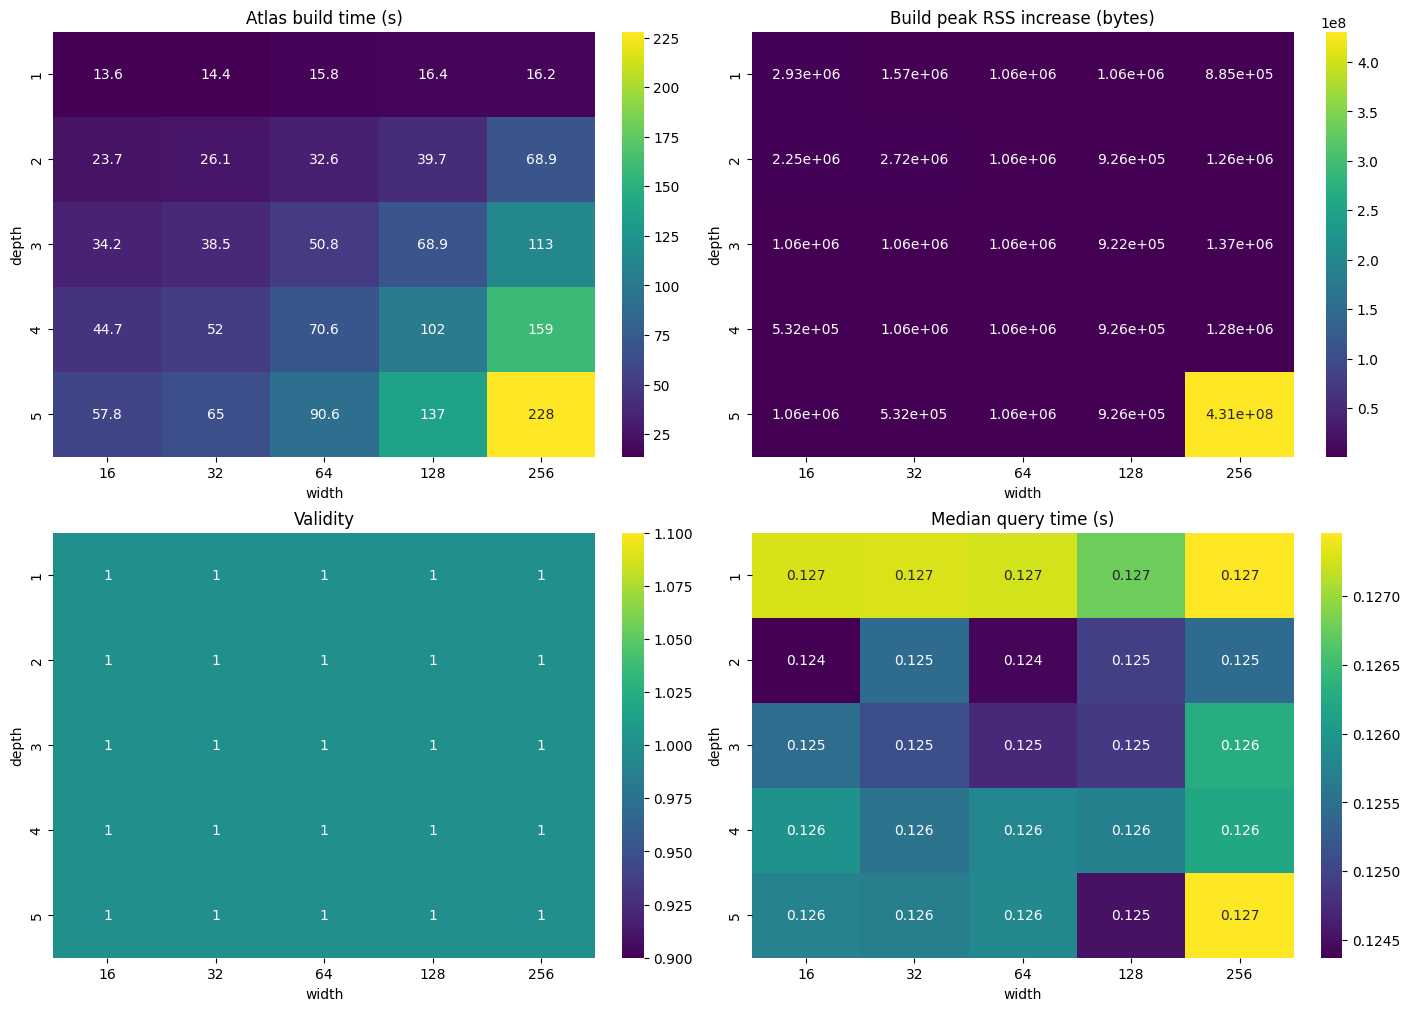

In [3]:
heatmap_metrics = {
    'build_wall_time_s': 'Atlas build time (s)',
    'build_rss_peak_delta_bytes': 'Build peak RSS increase (bytes)',
    'validity': 'Validity',
    'query_time_median_s': 'Median query time (s)',
}
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, (metric, title) in zip(axes.flat, heatmap_metrics.items()):
    matrix = summary.pivot(index='depth', columns='width', values=metric)
    sns.heatmap(matrix, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(title)
plt.show()

## Build cost versus parameter count

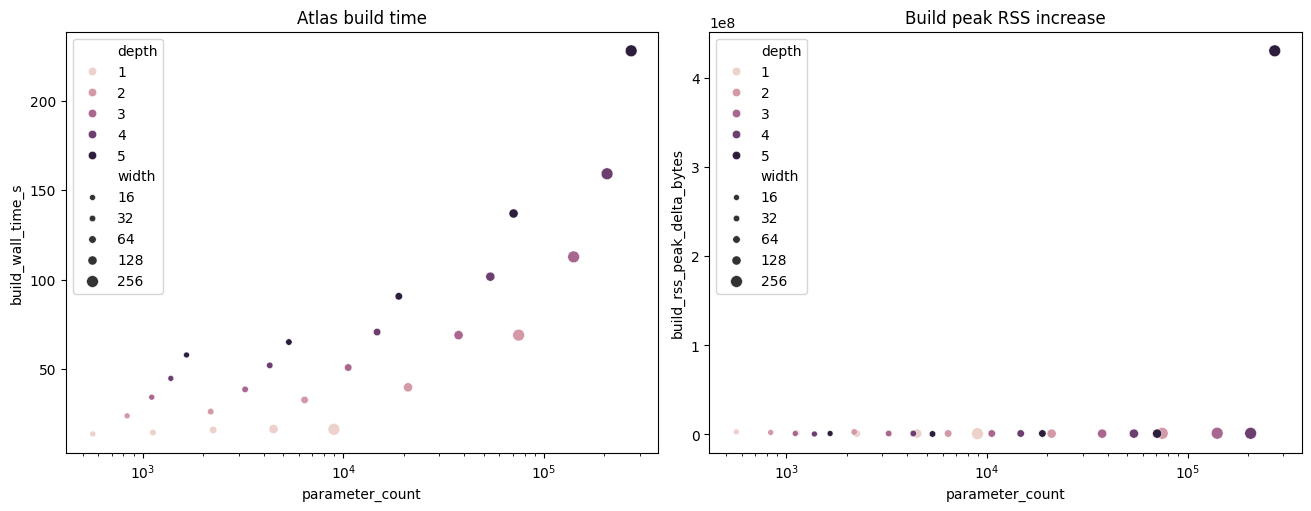

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.scatterplot(data=summary, x='parameter_count', y='build_wall_time_s', hue='depth', size='width', ax=axes[0])
sns.scatterplot(data=summary, x='parameter_count', y='build_rss_peak_delta_bytes', hue='depth', size='width', ax=axes[1])
for ax in axes:
    ax.set_xscale('log')
axes[0].set_title('Atlas build time')
axes[1].set_title('Build peak RSS increase')
plt.show()

## Marginal trends by width and depth

,build_wall_time_s,build_rss_peak_delta_bytes,validity,query_time_median_s
width,,,,
16,34.793514,1567129.600000,1.000000,0.125756
32,39.207095,1390182.400000,1.000000,0.125813
64,52.089050,1060044.800000,1.000000,0.125600
128,72.696139,951910.400000,1.000000,0.125369
256,116.981141,87076044.800000,1.000000,0.126570


,build_wall_time_s,build_rss_peak_delta_bytes,validity,query_time_median_s
depth,,,,
1,15.279094,1501593.600000,1.000000,0.127204
2,38.209647,1644134.400000,1.000000,0.124922
3,61.005824,1094451.200000,1.000000,0.125299
4,85.606619,971571.200000,1.000000,0.125840
5,115.665754,86833561.600000,1.000000,0.125842


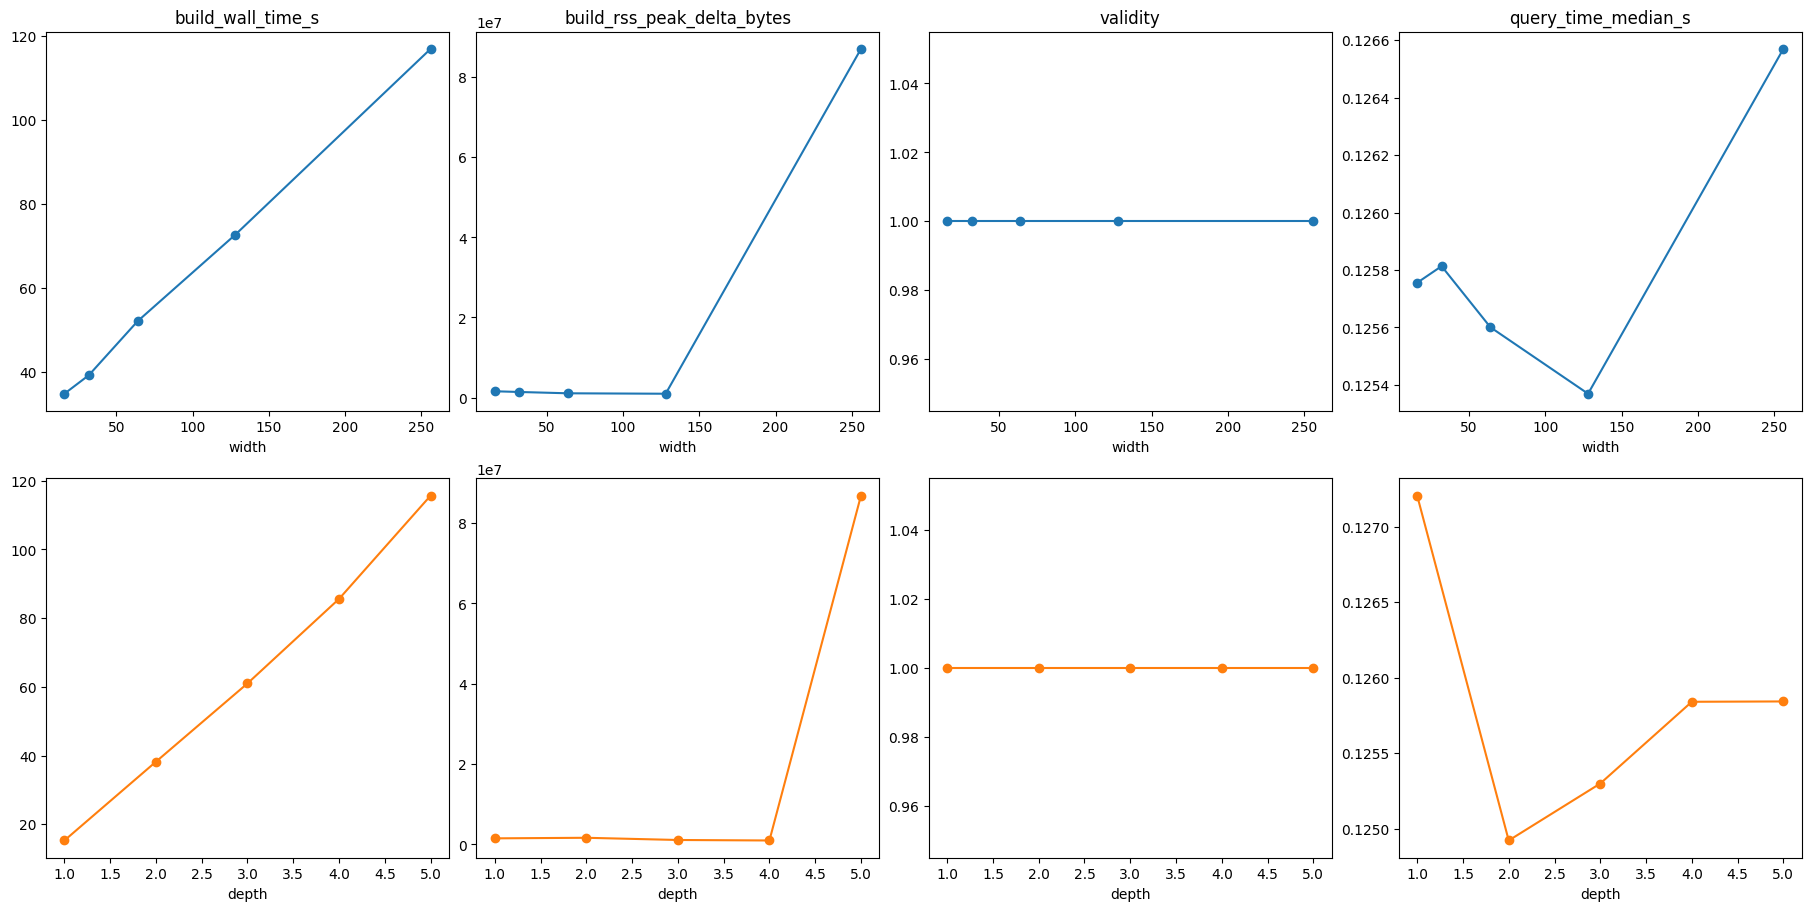

In [5]:
trend_metrics = ['build_wall_time_s', 'build_rss_peak_delta_bytes', 'validity', 'query_time_median_s']
by_width = summary.groupby('width')[trend_metrics].mean(numeric_only=True)
by_depth = summary.groupby('depth')[trend_metrics].mean(numeric_only=True)
display(by_width.style.set_caption('Marginal means by width'))
display(by_depth.style.set_caption('Marginal means by depth'))
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
for column, metric in enumerate(trend_metrics):
    axes[0, column].plot(by_width.index, by_width[metric], marker='o')
    axes[0, column].set_title(metric)
    axes[0, column].set_xlabel('width')
    axes[1, column].plot(by_depth.index, by_depth[metric], marker='o', color='tab:orange')
    axes[1, column].set_xlabel('depth')
plt.show()

## Empirical CertCF build-time complexity

Here, CertCF *training* means atlas construction (`build_wall_time_s`), not classifier training. Candidate scaling laws are compared with leave-one-architecture-out (LOO) predictions. This is more informative than choosing a curve from in-sample $R^2$ alone.

,model,coefficients_including_intercept,LOO_MAE_s,LOO_RMSE_s,LOO_MAPE_pct,LOO_predictive_R2,in_sample_R2
0,Quadratic depth/width,6,2.70,4.30,4.82,0.993,0.997
1,Layer-width interaction (selected),3,2.97,4.55,5.43,0.992,0.996
2,Parameter count + depth,3,7.60,10.24,13.25,0.959,0.970
3,Linear parameter count,2,19.67,23.00,55.03,0.795,0.821
4,Power law in parameter count,2,20.19,26.25,44.23,0.733,0.785
5,Depth + width,3,18.79,26.94,59.14,0.719,0.824


**Selected empirical law:** $\widehat{T}_{build} = 5.70 + 7.82D + 0.1713(D-1)W$ seconds.

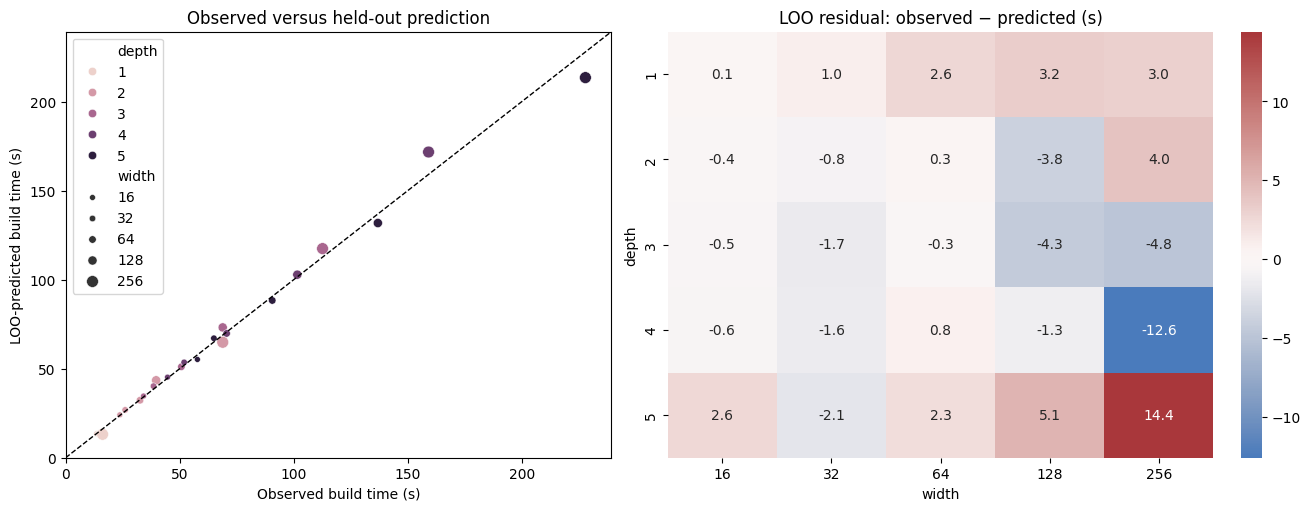

,architecture_id,depth,width,parameter_count,build_wall_time_s,LOO_predicted_build_time_s,LOO_residual_s
0,depth_01_width_016,1,16,562,13.590069,13.509683,0.080386
1,depth_01_width_032,1,32,1122,14.401450,13.399040,1.002410
2,depth_01_width_064,1,64,2242,15.830139,13.204219,2.625920
3,depth_01_width_128,1,128,4482,16.373788,13.130085,3.243703
4,depth_01_width_256,1,256,8962,16.200024,13.153780,3.046244
5,depth_02_width_016,2,16,834,23.745322,24.106077,-0.360755
6,depth_02_width_032,2,32,2178,26.097542,26.873015,-0.775473
7,depth_02_width_064,2,64,6402,32.629047,32.284741,0.344306
8,depth_02_width_128,2,128,20994,39.681095,43.502534,-3.821439
9,depth_02_width_256,2,256,74754,68.895231,64.871919,4.023312


In [6]:
from IPython.display import Markdown
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

scaling = summary.sort_values(['depth', 'width']).reset_index(drop=True).copy()
y_build = scaling['build_wall_time_s'].to_numpy()
depth = scaling['depth'].to_numpy(dtype=float)
width = scaling['width'].to_numpy(dtype=float)
parameters = scaling['parameter_count'].to_numpy(dtype=float)
architecture = np.column_stack([depth, width])
layer_width = np.column_stack([depth, (depth - 1.0) * width])

candidate_models = {
    'Linear parameter count': (LinearRegression(), parameters[:, None], 2),
    'Power law in parameter count': (
        TransformedTargetRegressor(
            regressor=LinearRegression(), func=np.log, inverse_func=np.exp,
        ),
        np.log(parameters[:, None]),
        2,
    ),
    'Parameter count + depth': (
        LinearRegression(), np.column_stack([parameters, depth]), 3,
    ),
    'Depth + width': (LinearRegression(), architecture, 3),
    'Layer-width interaction (selected)': (
        LinearRegression(), layer_width, 3,
    ),
    'Quadratic depth/width': (
        make_pipeline(
            PolynomialFeatures(degree=2, include_bias=False),
            LinearRegression(),
        ),
        architecture,
        6,
    ),
}

loo = LeaveOneOut()
comparison_rows = []
loo_predictions = {}
for model_name, (model, features, coefficient_count) in candidate_models.items():
    prediction = cross_val_predict(model, features, y_build, cv=loo)
    fitted = model.fit(features, y_build)
    loo_predictions[model_name] = prediction
    comparison_rows.append({
        'model': model_name,
        'coefficients_including_intercept': coefficient_count,
        'LOO_MAE_s': mean_absolute_error(y_build, prediction),
        'LOO_RMSE_s': mean_squared_error(y_build, prediction) ** 0.5,
        'LOO_MAPE_pct': np.mean(np.abs((y_build - prediction) / y_build)) * 100.0,
        'LOO_predictive_R2': r2_score(y_build, prediction),
        'in_sample_R2': r2_score(y_build, fitted.predict(features)),
    })

model_comparison = (pd.DataFrame(comparison_rows)
                    .sort_values(['LOO_RMSE_s', 'coefficients_including_intercept'])
                    .reset_index(drop=True))
display(model_comparison.style.format({
    'LOO_MAE_s': '{:.2f}', 'LOO_RMSE_s': '{:.2f}',
    'LOO_MAPE_pct': '{:.2f}', 'LOO_predictive_R2': '{:.3f}',
    'in_sample_R2': '{:.3f}',
}).set_caption('Candidate build-time scaling models (lower LOO error is better)'))

selected_name = 'Layer-width interaction (selected)'
selected_model = LinearRegression().fit(layer_width, y_build)
intercept, depth_coef, layer_width_coef = (
    selected_model.intercept_, *selected_model.coef_,
)
display(Markdown(
    rf'**Selected empirical law:** $\widehat{{T}}_{{build}} = '
    rf'{intercept:.2f} + {depth_coef:.2f}D + '
    rf'{layer_width_coef:.4f}(D-1)W$ seconds.'
))

selected_loo = loo_predictions[selected_name]
prediction_frame = scaling[
    ['architecture_id', 'depth', 'width', 'parameter_count', 'build_wall_time_s']
].copy()
prediction_frame['LOO_predicted_build_time_s'] = selected_loo
prediction_frame['LOO_residual_s'] = y_build - selected_loo

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.scatterplot(
    data=prediction_frame, x='build_wall_time_s',
    y='LOO_predicted_build_time_s', hue='depth', size='width', ax=axes[0],
)
limits = [0.0, 1.05 * max(y_build.max(), selected_loo.max())]
axes[0].plot(limits, limits, '--', color='black', linewidth=1)
axes[0].set(xlim=limits, ylim=limits, title='Observed versus held-out prediction',
            xlabel='Observed build time (s)', ylabel='LOO-predicted build time (s)')
residual_grid = prediction_frame.pivot(index='depth', columns='width', values='LOO_residual_s')
sns.heatmap(residual_grid, annot=True, fmt='.1f', center=0, cmap='vlag', ax=axes[1])
axes[1].set_title('LOO residual: observed − predicted (s)')
plt.show()
prediction_frame

The quadratic model has the smallest raw LOO error, but only by a small margin and with twice as many coefficients as the selected interaction law. The selected model is preferred as the compact descriptive result: it captures the nearly width-independent cost at depth 1 and the increasing width penalty as hidden layers are added. It is an empirical interpolation over $D\in[1,5]$ and $W\in[16,256]$, not an asymptotic complexity proof. With one timing per architecture and one experimental seed, it should not be extrapolated beyond the grid or used to claim uncertainty bounds.

## Failures and resource limits

In [7]:
failure_rows = queries.loc[~queries['success'], ['architecture_id', 'query_idx', 'error']]
failure_summary = (failure_rows.groupby(['architecture_id', 'error'], dropna=False).size()
                   .rename('count').reset_index().sort_values(['architecture_id', 'count'], ascending=[True, False]))
resource_limits = summary.loc[
    (summary['validity'] < 1.0) | ~np.isfinite(summary['build_wall_time_s']),
    ['architecture_id', 'validity', 'effective_lirpa_batch_size', 'build_wall_time_s'],
]
display(failure_summary if len(failure_summary) else pd.DataFrame({'status': ['No query failures']}))
display(resource_limits if len(resource_limits) else pd.DataFrame({'status': ['No recorded resource limits']}))

,status
0,No query failures


,status
0,No recorded resource limits
